# 1. DATA LOADING AND PREPROCESSING

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset
FILE_PATH = 'ncrb.csv'
df = pd.read_csv(FILE_PATH)

print(f"\nInitial dataset shape: {df.shape}")

# Standardize columns
df['year'] = df['year'].astype(int)
for col in ['state', 'city', 'crime_head', 'crime_category']:
    df[col] = df[col].astype(str).str.lower().str.strip()

# Convert numeric columns
for col in ['incidence', 'victims']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['crime_rate'] = pd.to_numeric(df['crime_rate'], errors='coerce')

# Filter to keep only 'total' category
df = df[df['crime_category'] == 'total'].copy()

# Remove aggregate rows
AGGREGATE_FILTERS = ['total', 'total cities', 'all india']
for col in ['state', 'city', 'crime_head']:
    df = df[~df[col].isin(AGGREGATE_FILTERS)]

# Remove aggregate crime heads
CRIME_HEAD_AGGREGATES = [
    "total ipc crimes against women",
    "total sll crimes against women",
    "total crimes against women"
]
df = df[~df['crime_head'].isin(CRIME_HEAD_AGGREGATES)]

# Calculate population
df['population'] = np.where(
    df['crime_rate'] > 0,
    (df['incidence'] * 100000) / df['crime_rate'],
    np.nan
)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill population values
df['population'] = df.groupby(['state', 'city'])['population'].transform(
    lambda x: x.fillna(x.median())
)
df['population'] = df['population'].fillna(df['population'].median())

# Select final columns
final_df = df[['city', 'state', 'year', 'population', 'crime_head', 'incidence', 'crime_rate']].copy()
final_df = final_df.rename(columns={'incidence': 'crime_count'})

print(f"After preprocessing: {final_df.shape}")


C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (



Initial dataset shape: (8280, 11)
After preprocessing: (3097, 7)


## 2. Exploratory Data Analysis (EDA)


--- Shape of Dataset ---
(3097, 7)

--- Column Info ---
<class 'pandas.DataFrame'>
Index: 3097 entries, 0 to 8276
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         3097 non-null   str    
 1   state        3097 non-null   str    
 2   year         3097 non-null   int32  
 3   population   3097 non-null   float64
 4   crime_head   3097 non-null   str    
 5   crime_count  3097 non-null   float64
 6   crime_rate   3097 non-null   float64
dtypes: float64(3), int32(1), str(3)
memory usage: 348.6 KB
None

--- Missing Values ---
city           0
state          0
year           0
population     0
crime_head     0
crime_count    0
crime_rate     0
dtype: int64

--- Summary Statistics ---
              year    population  crime_count   crime_rate
count  3097.000000  3.097000e+03  3097.000000  3097.000000
mean   2019.607362  2.814998e+06   112.740717     4.152438
std       2.241734  2.351829e+06   363.369185    

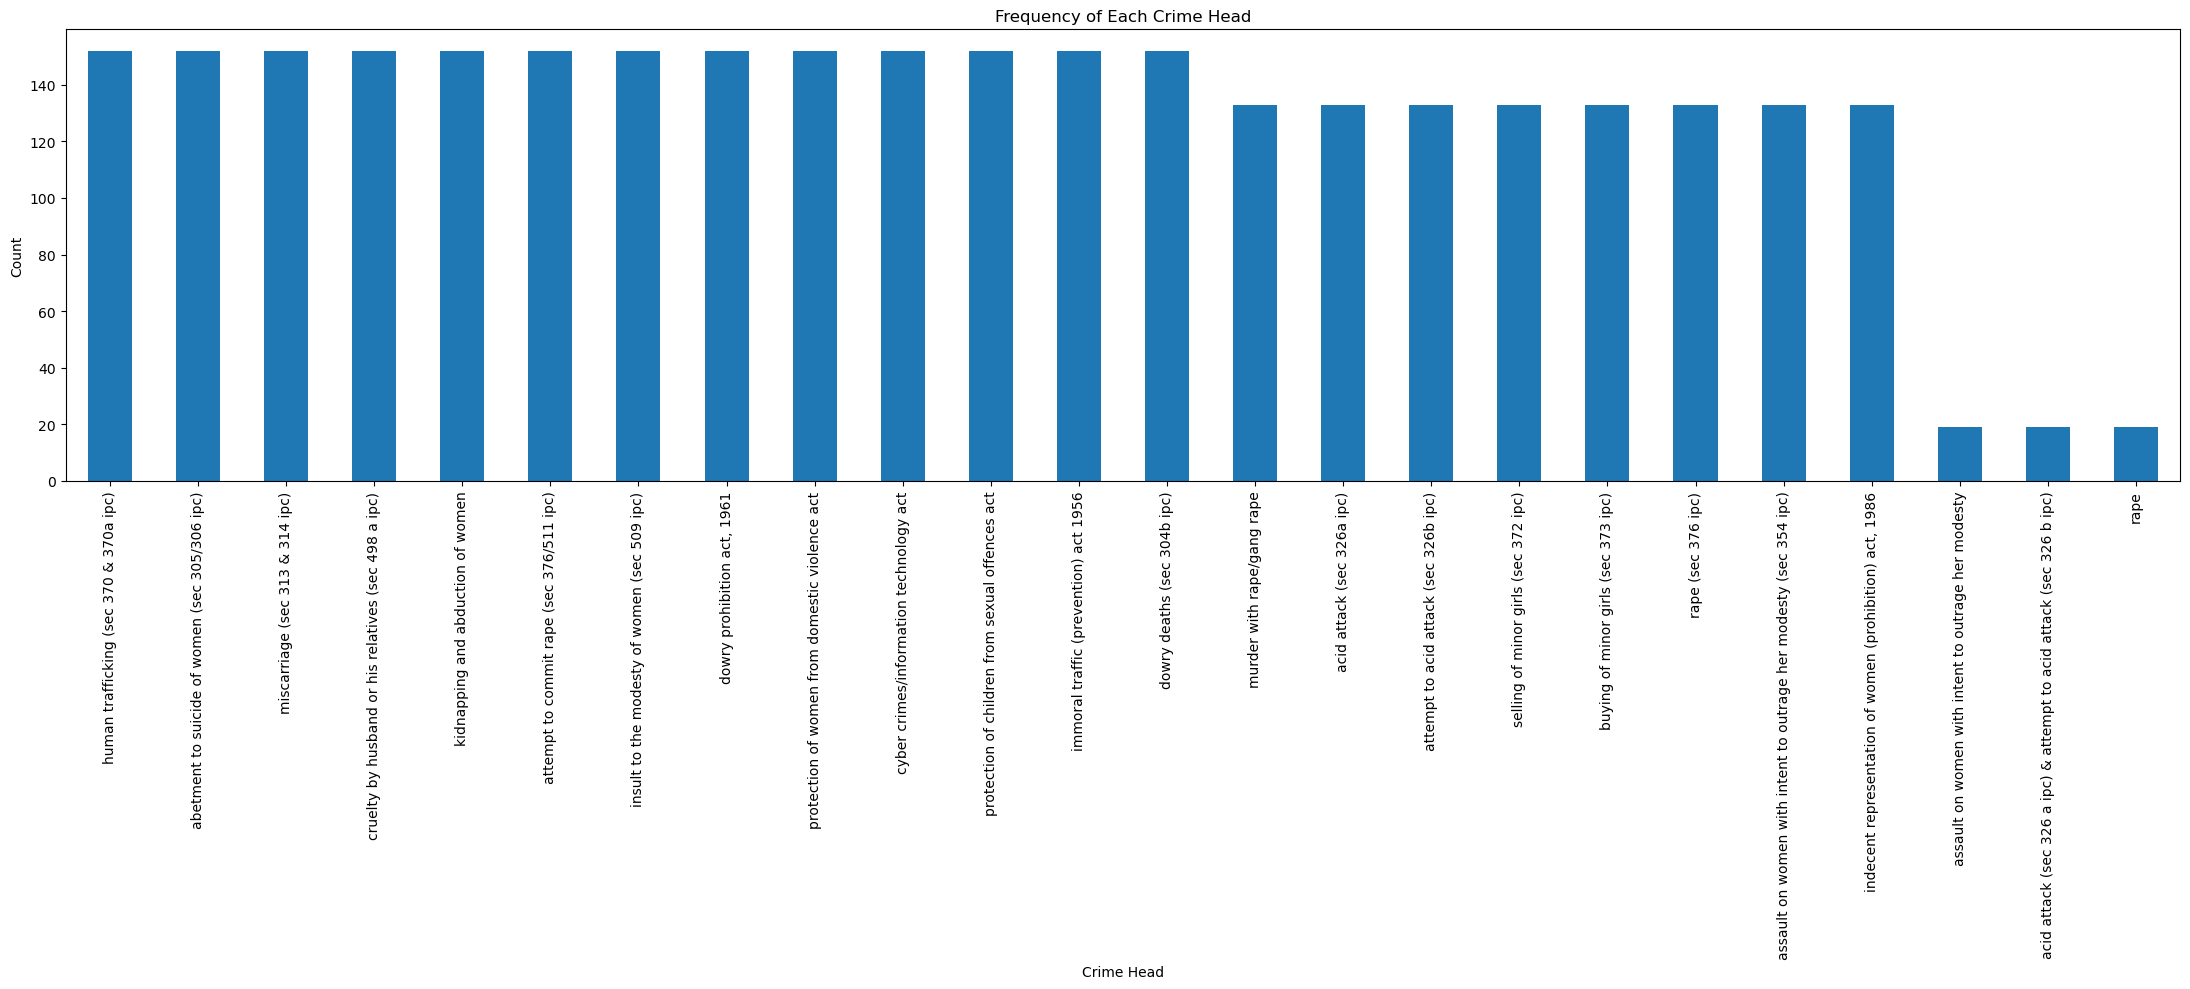

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = final_df

# BASIC DATA CHECKS
print("\n--- Shape of Dataset ---")
print(df.shape)

print("\n--- Column Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

# UNIVARIATE ANALYSIS
# Crime Heads Count
plt.figure(figsize=(22,10))
df["crime_head"].value_counts().plot(kind="bar")
plt.title("Frequency of Each Crime Head")
plt.xlabel("Crime Head")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


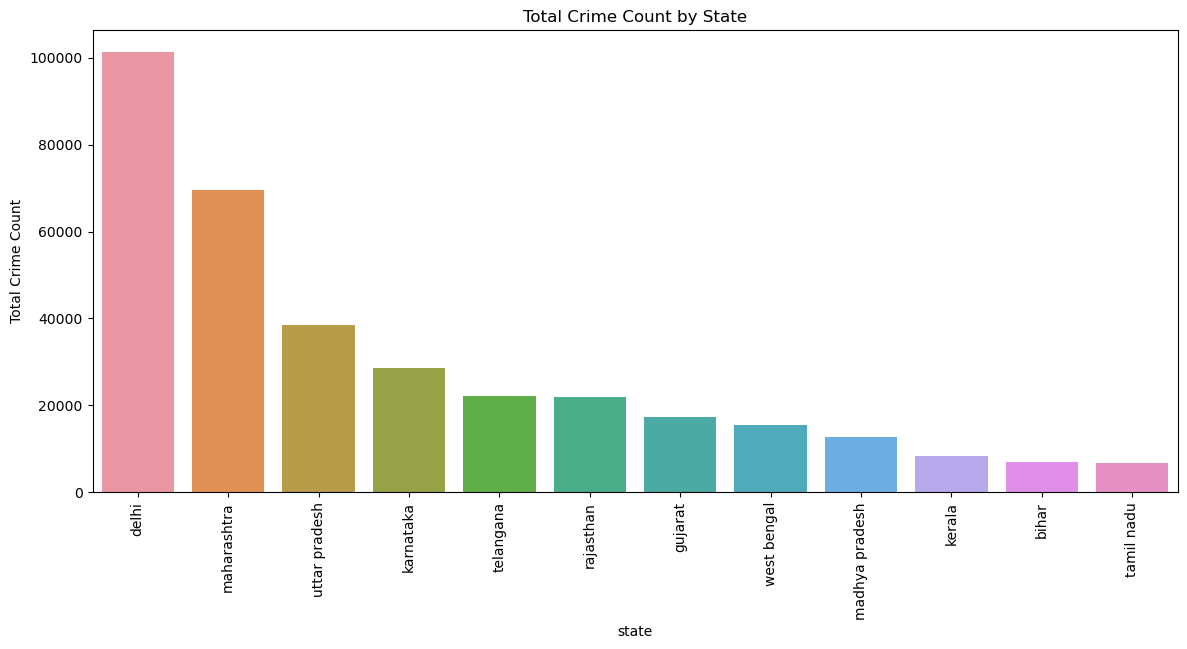

In [3]:
# BIVARIATE ANALYSIS 
# Crime Count vs State
plt.figure(figsize=(14,6))
state_crime = df.groupby("state")["crime_count"].sum().sort_values(ascending=False)
sns.barplot(x=state_crime.index, y=state_crime.values)
plt.xticks(rotation=90)
plt.title("Total Crime Count by State")
plt.ylabel("Total Crime Count")
plt.show()

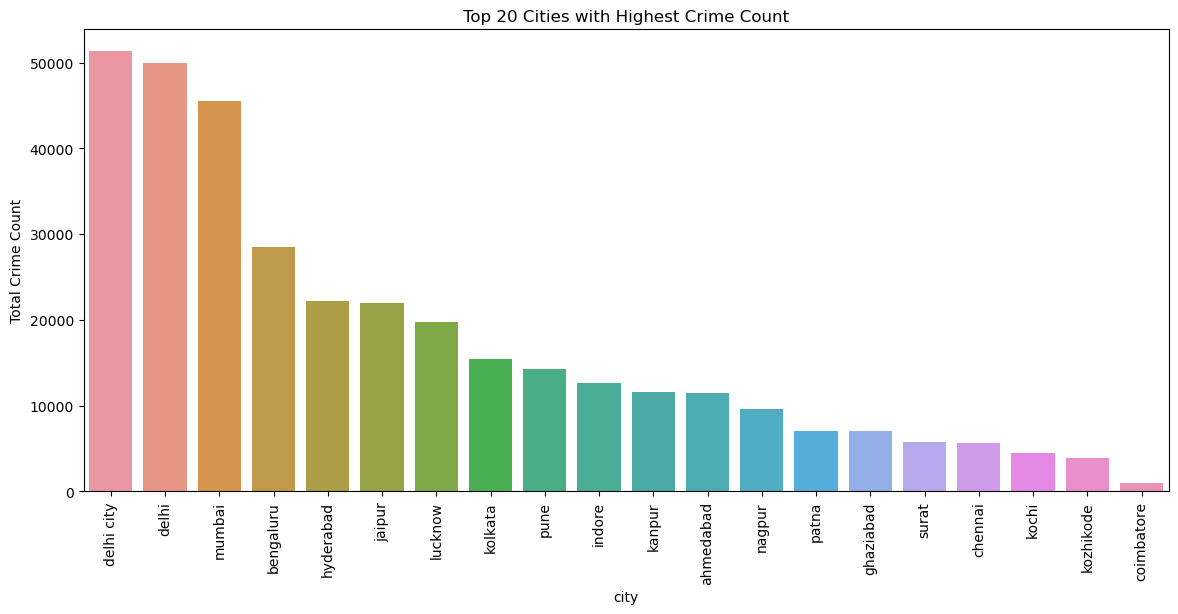

In [4]:
# BIVARIATE ANALYSIS
# City-wise highest crime
plt.figure(figsize=(14,6))
city_crime = df.groupby("city")["crime_count"].sum().sort_values(ascending=False).head(20)
sns.barplot(x=city_crime.index, y=city_crime.values)
plt.xticks(rotation=90)
plt.title("Top 20 Cities with Highest Crime Count")
plt.ylabel("Total Crime Count")
plt.show()

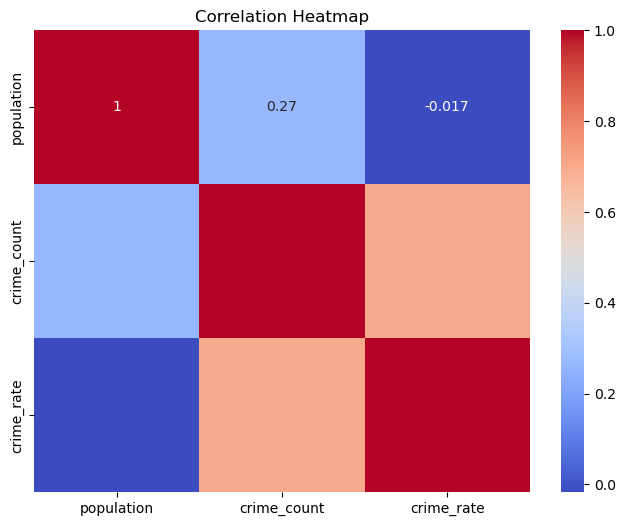

In [5]:
# MULTIVARIATE ANALYSIS
# Correlation Heatmap
num_cols = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

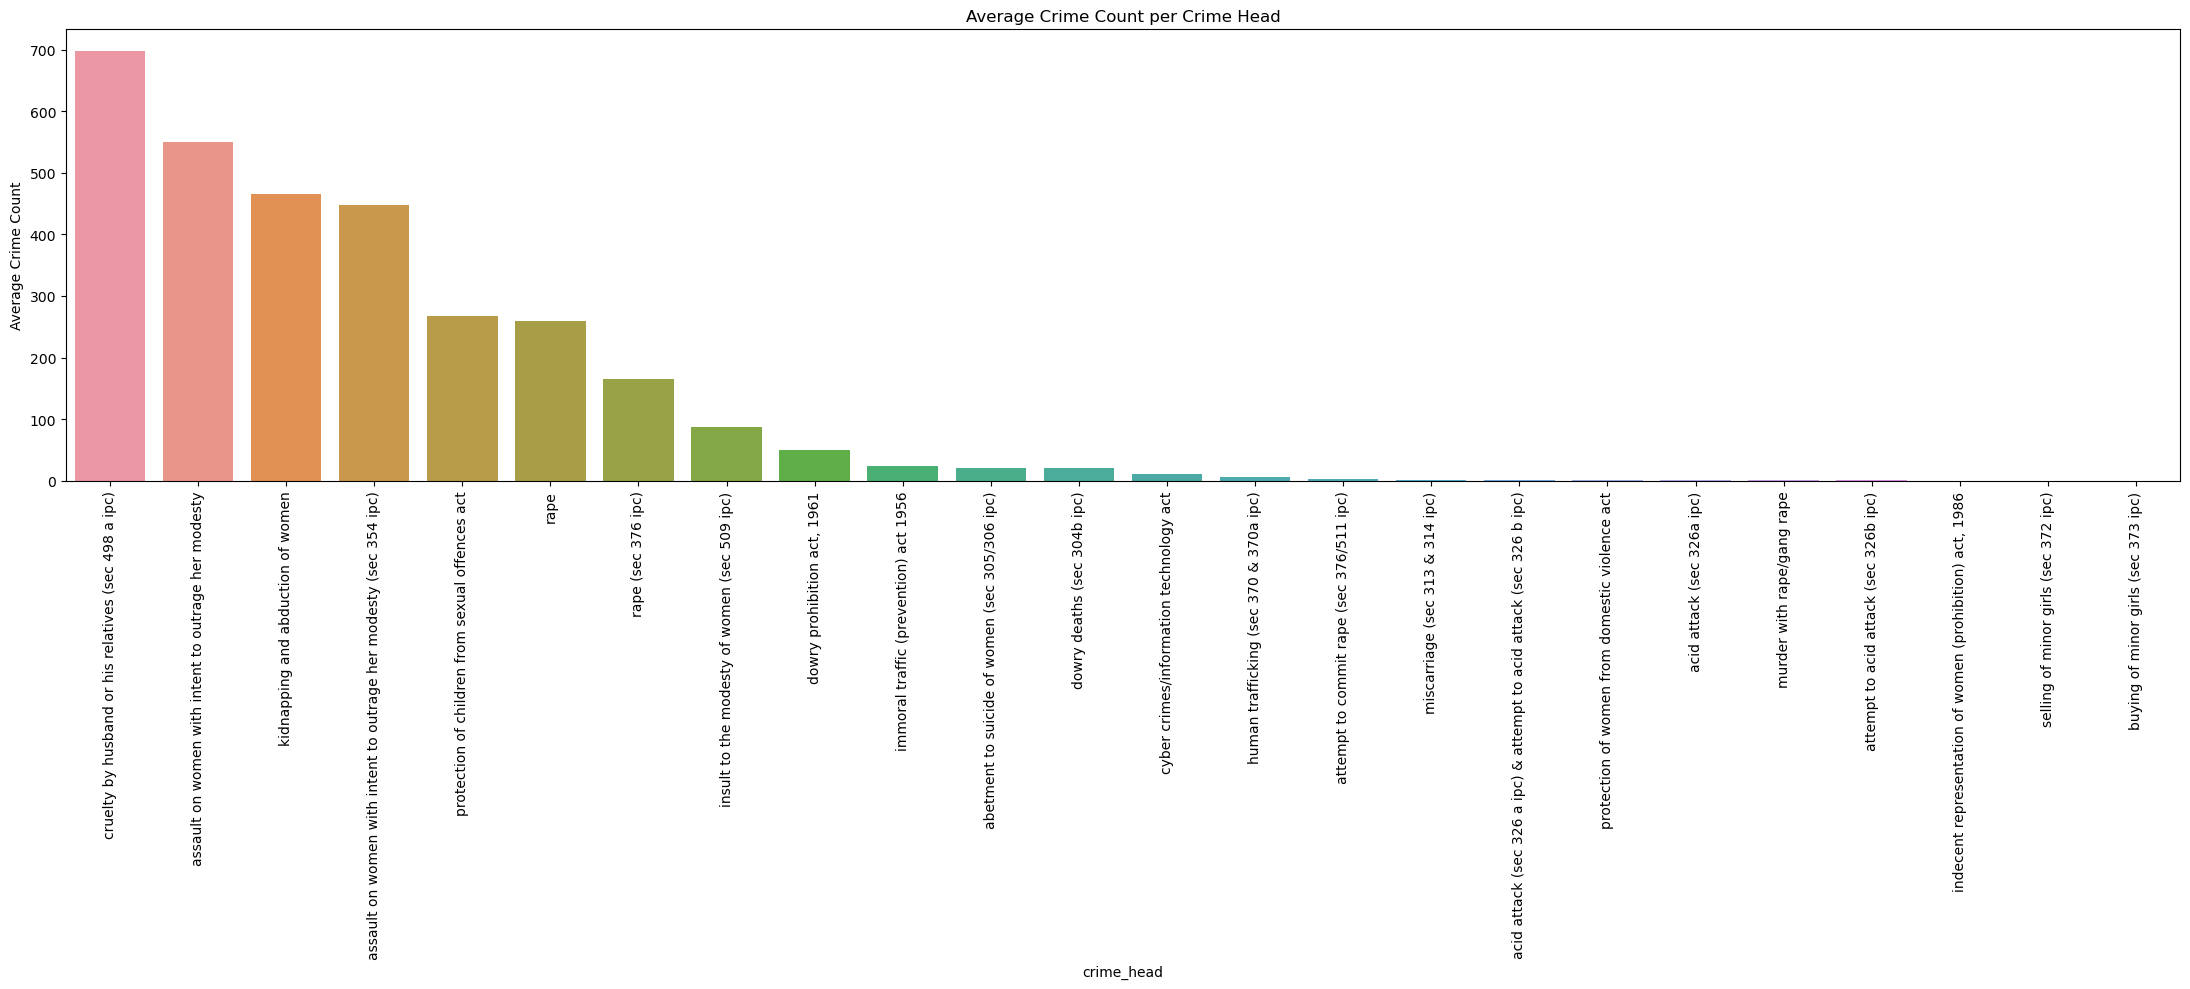

In [6]:
# CRIME HEAD vs CRIME COUNT
plt.figure(figsize=(22,10))
avg_crime = df.groupby("crime_head")["crime_count"].mean().sort_values(ascending=False)
sns.barplot(x=avg_crime.index, y=avg_crime.values)
plt.xticks(rotation=90)
plt.title("Average Crime Count per Crime Head")
plt.ylabel("Average Crime Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. FEATURE ENGINEERING

In [7]:
def create_simplified_features(df):
    df = df.sort_values(by=["city", "state", "crime_head", "year"]).reset_index(drop=True)
    
    # 1 lag feature for crime rate
    df["crime_rate_lag1"] = df.groupby(["city", "state", "crime_head"])["crime_rate"].shift(1)
    
    # State average (historical)
    df["state_avg_crime_rate"] = df.groupby(["state", "crime_head", "year"])["crime_rate"].transform("mean")
    df["state_avg_crime_rate_lag1"] = df.groupby(["state", "crime_head"])["state_avg_crime_rate"].shift(1)
    
    # Fill NaN with 0
    df = df.fillna(0)
    
    return df

final_df = create_simplified_features(final_df)
print("Features created")

Features created


In [8]:
final_df.head()

,city,state,year,population,crime_head,crime_count,crime_rate,crime_rate_lag1,state_avg_crime_rate,state_avg_crime_rate_lag1
0,ahmedabad,gujarat,2016,3.000000e+06,abetment to suicide of women (sec 305/306 ipc),21.0,0.7,0.0,0.65,0.00
1,ahmedabad,gujarat,2017,3.000000e+06,abetment to suicide of women (sec 305/306 ipc),24.0,0.8,0.7,0.80,0.65
2,ahmedabad,gujarat,2018,2.928571e+06,abetment to suicide of women (sec 305/306 ipc),41.0,1.4,0.8,1.20,0.80
3,ahmedabad,gujarat,2019,2.937500e+06,abetment to suicide of women (sec 305/306 ipc),47.0,1.6,1.4,1.55,1.20
4,ahmedabad,gujarat,2020,3.076923e+06,abetment to suicide of women (sec 305/306 ipc),40.0,1.3,1.6,1.10,1.55


In [9]:
final_df.to_csv("final_crime_data.csv",index=False)

## 4. TRAIN - TEST Split

In [10]:
# Split data: Train on years up to 2022, Testing on 2023
train_df = final_df[final_df["year"] <= 2022].copy()
test_df = final_df[final_df["year"] == 2023].copy() 

print(f"Training samples: {train_df.shape[0]}")
print(f"Test samples: {test_df.shape[0]}")

Training samples: 2698
Test samples: 399


## 5. Encoding

In [11]:
# Encode categorical variables
le_city = LabelEncoder()
le_state = LabelEncoder()
le_crime = LabelEncoder()

# Fit on all data
all_cities = pd.concat([train_df['city'], test_df['city']]).unique()
all_states = pd.concat([train_df['state'], test_df['state']]).unique()
all_crimes = pd.concat([train_df['crime_head'], test_df['crime_head']]).unique()

le_city.fit(all_cities)
le_state.fit(all_states)
le_crime.fit(all_crimes)

# Transform
train_df['city_encoded'] = le_city.transform(train_df['city'])
train_df['state_encoded'] = le_state.transform(train_df['state'])
train_df['crime_head_encoded'] = le_crime.transform(train_df['crime_head'])

test_df['city_encoded'] = le_city.transform(test_df['city'])
test_df['state_encoded'] = le_state.transform(test_df['state'])
test_df['crime_head_encoded'] = le_crime.transform(test_df['crime_head'])

In [12]:
import pickle
encoders = {
    "city": le_city,
    "state": le_state,
    "crime": le_crime
}

with open("encoders_epics.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [13]:
# 4. MINIMAL FEATURE SET
# Use ONLY essential features
feature_cols = [
    'city_encoded', 
    'state_encoded', 
    'crime_head_encoded',
    'crime_rate_lag1',
    'state_avg_crime_rate_lag1'
]

X_train = train_df[feature_cols]
y_train = train_df['crime_rate']

X_test = test_df[feature_cols]
y_test = test_df['crime_rate']

print(f"\nUsing {len(feature_cols)} features:")
print(feature_cols)


Using 5 features:
['city_encoded', 'state_encoded', 'crime_head_encoded', 'crime_rate_lag1', 'state_avg_crime_rate_lag1']


# 6. Evaluation Function and Hyperparamter Tuning

In [14]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

Parameters for hyperparamter tuning

In [15]:
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 6, 7, 8],
    'min_samples_split': [20, 25, 30],
    'min_samples_leaf': [10, 12, 15],
    'max_features': [0.4, 0.5, 0.6],
    'bootstrap': [True],
    'random_state': [42],
    'n_jobs': [-1]
}

In [16]:
gb_param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [20, 25, 30],
    'min_samples_leaf': [10, 12, 15],
    'subsample': [0.6, 0.7, 0.8],
    'max_features': [0.5, 0.6, 'sqrt'],
    'random_state': [42]
}

In [17]:
ridge_param_grid= {
    'alpha': [1.0, 10.0, 25.0, 50.0,100.0],
    'random_state': [42]
}

In [18]:
randomcv_models = [
                   ("RF", RandomForestRegressor(), rf_param_grid ),
                   ("Gboost",GradientBoostingRegressor(),gb_param_grid),
                ("Ridge",Ridge(),ridge_param_grid)
                   
                   ]

In [19]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits
---------------- Best Params for RF -------------------
{'random_state': 42, 'n_jobs': -1, 'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.6, 'max_depth': 7, 'bootstrap': True}
---------------- Best Params for Gboost -------------------
{'subsample': 0.8, 'random_state': 42, 'n_estimators': 100, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.1}
---------------- Best Params for Ridge -------------------
{'random_state': 42, 'alpha': 100.0}


In [20]:
# Best parameters after tuning

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=50,          
        max_depth=8,           
        min_samples_split=20,     
        min_samples_leaf=10,     
        bootstrap=True,
        random_state=42,
        max_features=0.6,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.01,       
        max_depth=5,              
        min_samples_split=30,
        min_samples_leaf=10,
        subsample=0.8,            
        max_features=0.6,
        random_state=42
    ),
        "Ridge": Ridge(
        alpha=100,               
        random_state=42
    )
}

# 7. TRAIN AND EVALUATE ALL MODELS

In [21]:
results = {}

for name, model in models.items():
    print(f"{name}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_test_pred = model.predict(X_test)
    
    # Evaluate
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'model': model
    }
    
    # Print
    print(f"TEST  | R2: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")


Random Forest
TEST  | R2: 0.8769 | RMSE: 4.5102 | MAE: 1.5966
Gradient Boosting
TEST  | R2: 0.8648 | RMSE: 4.7271 | MAE: 2.0177
Ridge
TEST  | R2: 0.9040 | RMSE: 3.9829 | MAE: 1.6070


In [22]:
# 9. SUMMARY TABLE

print("Comparison of all 3 models")
summary_data = []
for name, res in results.items():
    summary_data.append({
        'Model': name,
        'Test R2': f"{res['test_r2']:.4f}",
        'Test RMSE': f"{res['test_rmse']:.4f}",
        'Test MAE': f"{res['test_mae']:.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

Comparison of all 3 models
            Model Test R2 Test RMSE Test MAE
    Random Forest  0.8769    4.5102   1.5966
Gradient Boosting  0.8648    4.7271   2.0177
            Ridge  0.9040    3.9829   1.6070


In [23]:
best_model=Ridge(alpha=100,               
        random_state=42)

In [24]:
best_model.fit(X_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


In [25]:
with open("ridge_final_model_EPICS.pkl", "wb") as f:
    pickle.dump(best_model, f)

### Using Ridge as it has highest R2 score

In [26]:
def predict_crime_rate_current_year():
  
    # 1. Take user input
    state_input = input("Enter State: ").strip()
    city_input = input("Enter City: ").strip()
    crime_input = input("Enter Crime Head: ").strip()

    # 2. Normalize inputs to match dataset
    state = state_input.lower()
    city = city_input.lower()
    crime_head = crime_input.lower()

    # 3. Validate presence in dataset
    if state not in final_df['state'].unique():
        print("State not found in dataset")
        return

    if city not in final_df['city'].unique():
        print("City not found in dataset")
        return
    if crime_head not in final_df['crime_head'].unique():
        print("Crime Head not found in dataset")
        return

    # 4. Encode using YOUR encoders
    state_enc = le_state.transform([state])[0]
    city_enc = le_city.transform([city])[0]
    crime_enc = le_crime.transform([crime_head])[0]
    # 5. Fetch latest historical values

    city_hist = final_df[
        (final_df['state'] == state) &
        (final_df['city'] == city) &
        (final_df['crime_head'] == crime_head)
    ].sort_values('year')

    if city_hist.empty:
        print("No historical data available for this combination")
        return

    crime_rate_lag1 = city_hist.iloc[-1]['crime_rate']

    state_hist = final_df[
        (final_df['state'] == state) &
        (final_df['crime_head'] == crime_head)
    ].sort_values('year')

    state_avg_crime_rate_lag1 = state_hist.iloc[-1]['state_avg_crime_rate']

    # 6. Model input (EXACT FEATURE ORDER)
    X_input = pd.DataFrame([{
        'city_encoded': city_enc,
        'state_encoded': state_enc,
        'crime_head_encoded': crime_enc,
        'crime_rate_lag1': crime_rate_lag1,
        'state_avg_crime_rate_lag1': state_avg_crime_rate_lag1
    }])

    # 7. Predict

    prediction = best_model.predict(X_input)[0]
    crime_2022_row = final_df[
    (final_df['state'] == state) &
    (final_df['city'] == city) &
    (final_df['crime_head'] == crime_head) &
    (final_df['year'] == 2022)
]
    if not crime_2022_row.empty:
        crime_rate_2022 = crime_2022_row.iloc[0]['crime_rate']
    else:
        crime_rate_2022 = crime_rate_lag1  # fallback
    if prediction > crime_rate_2022:
        trend = "Increasing Crime"
    elif prediction < crime_rate_2022:
        trend = "Decreasing Crime"
    else:
        trend = " No Change"


    print("\n Crime Rate Prediction (Current Year)")
    print(f"State      : {state_input}")
    print(f"City       : {city_input}")
    print(f"Crime Head : {crime_input}")
    print(f"Predicted Crime Rate: {round(prediction, 2)}")
    print(f"Trend Compared to previous year: {trend}")



In [ ]:
predict_crime_rate_current_year()